In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load binary prediction mask (ensure it's binary: 0 and 255 or 0 and 1)
mask_path = "/mnt/intenso/masterarbeit/predictions/250604_unet_resnet34_subset.tif"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print(mask)
# Ensure binary: convert anything >0 to 255
_, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


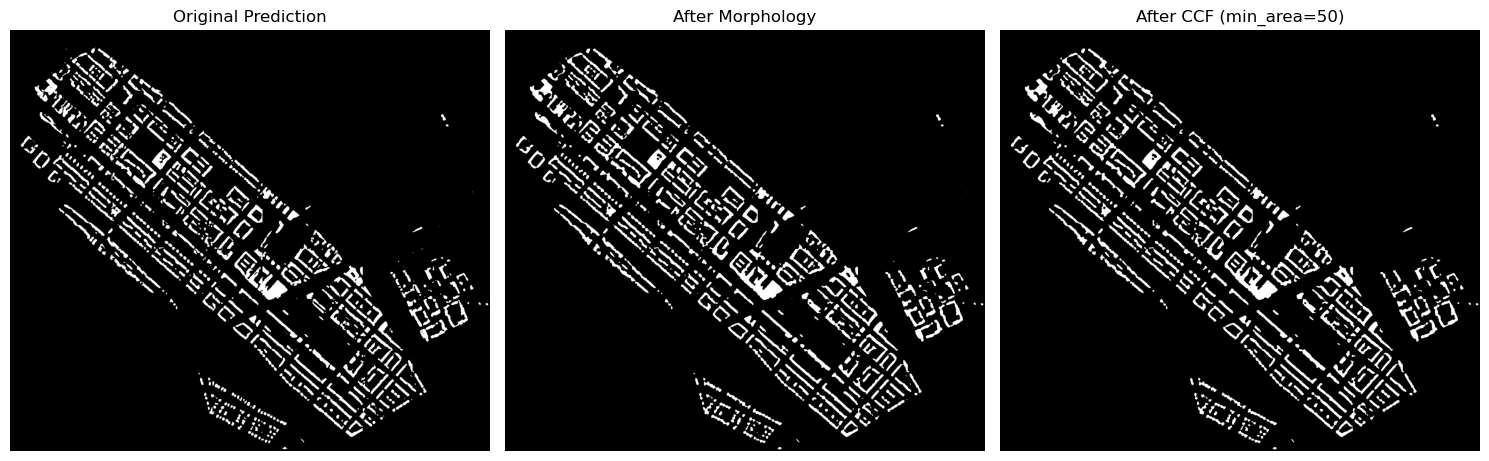

In [28]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read grayscale GeoTIFF with rasterio
with rasterio.open("/mnt/intenso/masterarbeit/predictions/250604_unet_resnet34_subset.tif") as src:
    image = src.read(1)  # Band 1
    profile = src.profile  # Keep for saving later

# Threshold the prediction if it's not already binary
# (Skip if already 0/1 or 0/255 mask)
mask = (image > 0).astype(np.uint8)

# Morphological opening (remove speckles)
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

# Morphological closing (fill holes)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

# Connected Component Filtering (remove small blobs)
min_area = 50  # pixels
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
mask_ccf = np.zeros_like(mask)
for i in range(1, num_labels):  # skip background
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        mask_ccf[labels == i] = 1

# Plotting
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Prediction")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("After Morphology")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_ccf, cmap='gray')
plt.title(f"After CCF (min_area={min_area})")
plt.axis("off")

plt.tight_layout()
plt.show()


In [29]:
import rasterio

# Ensure output is uint8 (rasterio expects known dtypes)
mask_out = mask_ccf.astype(np.uint8)

# Optionally, update the dtype in the profile
profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw'  # Optional: use LZW compression to reduce file size
)

# Write to a new GeoTIFF file
with rasterio.open("/mnt/intenso/masterarbeit/predictions/250604_cleaned.tif", "w", **profile) as dst:
    dst.write(mask_out, 1)  # Write to band 1
